Dataset Summary:
 - paper:
   Tot. Images: 712
   Sizes: [200 300]
   Mean Class Brightness: 116.13810074257957
   Std Class Brightness: 10.383552042815877


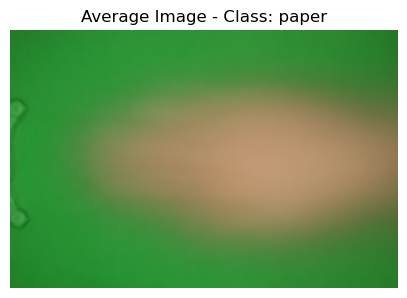

 - rock:
   Tot. Images: 726
   Sizes: [200 300]
   Mean Class Brightness: 113.87459168498621
   Std Class Brightness: 9.705818166786603


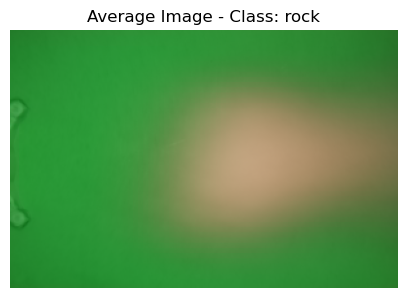

 - scissors:
   Tot. Images: 750
   Sizes: [200 300]
   Mean Class Brightness: 113.18805738682222
   Std Class Brightness: 10.090162478846906


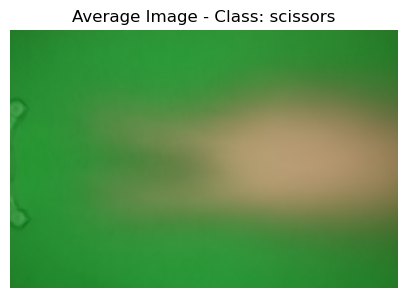

None


In [ ]:
import os
from PIL import Image
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

def explore_dataset(data_dir):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    avg_img = np.zeros((200,300, 3), dtype=np.float64)

    print("Dataset Summary:")
    for cls in classes:
        print(f" - {cls}:")
        cls_dir = os.path.join(data_dir, cls)
        images = os.listdir(cls_dir)
        num_images = 0
        sizes = []
        brightness_values = []
        accumulated_array = np.empty_like(avg_img)


        for i in images:
            img_path = os.path.join(cls_dir, i)
            with Image.open(img_path) as img:
                if img.mode != "RGB":
                    img = img.convert("RGB")
                sizes.append(img.size)
                img_array = np.array(img, dtype=np.float64)
                accumulated_array += img_array

                # Formula di luma CCIR 601
                brightness = np.mean(0.299 * img_array[:,:,0] + 0.587 * img_array[:,:,1] + 0.114 * img_array[:,:,2])
                brightness_values.append(brightness)
            num_images += 1 
        
        avg_img = (accumulated_array / num_images) / 255.0
        class_mean_brightness = np.mean(brightness_values)
        class_std_brightness = np.std(brightness_values)
        
        print(f"   Tot. Images: {num_images}")
        print(f"   Sizes: {np.unique(sizes)}")
        print(f"   Mean Class Brightness: {class_mean_brightness}")
        print(f"   Std Class Brightness: {class_std_brightness}")
        
        plt.figure(figsize=(5,5))
        plt.imshow(avg_img)
        plt.title(f"Average Image - Class: {cls}")
        plt.axis("off")
        plt.show()
    


explore_dataset("../data/raw")


--- 1. Quantitative & Technical Analysis ---

Class: paper
 - Images count: 712
 - Image sizes encountered (W, H): [(300, 200)]
 - Color modes encountered: ['RGB']
 - Mean Brightness: 116.14
 - Std Brightness: 10.38


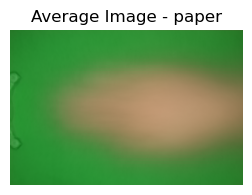


Class: rock
 - Images count: 726
 - Image sizes encountered (W, H): [(300, 200)]
 - Color modes encountered: ['RGB']
 - Mean Brightness: 113.87
 - Std Brightness: 9.71


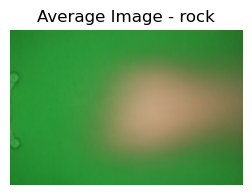


Class: scissors
 - Images count: 750
 - Image sizes encountered (W, H): [(300, 200)]
 - Color modes encountered: ['RGB']
 - Mean Brightness: 113.19
 - Std Brightness: 10.09


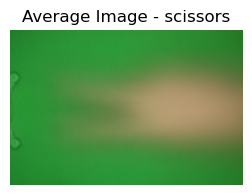


--- Overall Dataset Statistics ---
Total images: 2188
Global Pixel Min: 0.0
Global Pixel Max: 255.0
Global Pixel Mean: 95.88
Global Pixel Std: 54.58


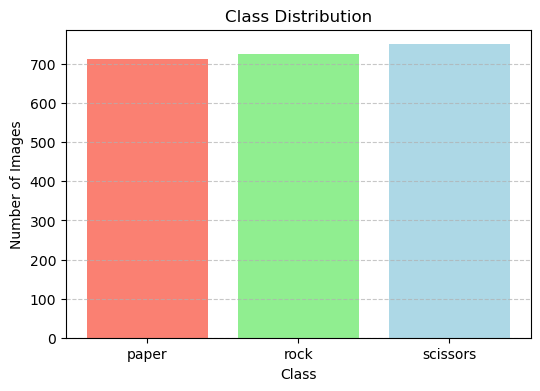


--- 2. Qualitative Inspection ---


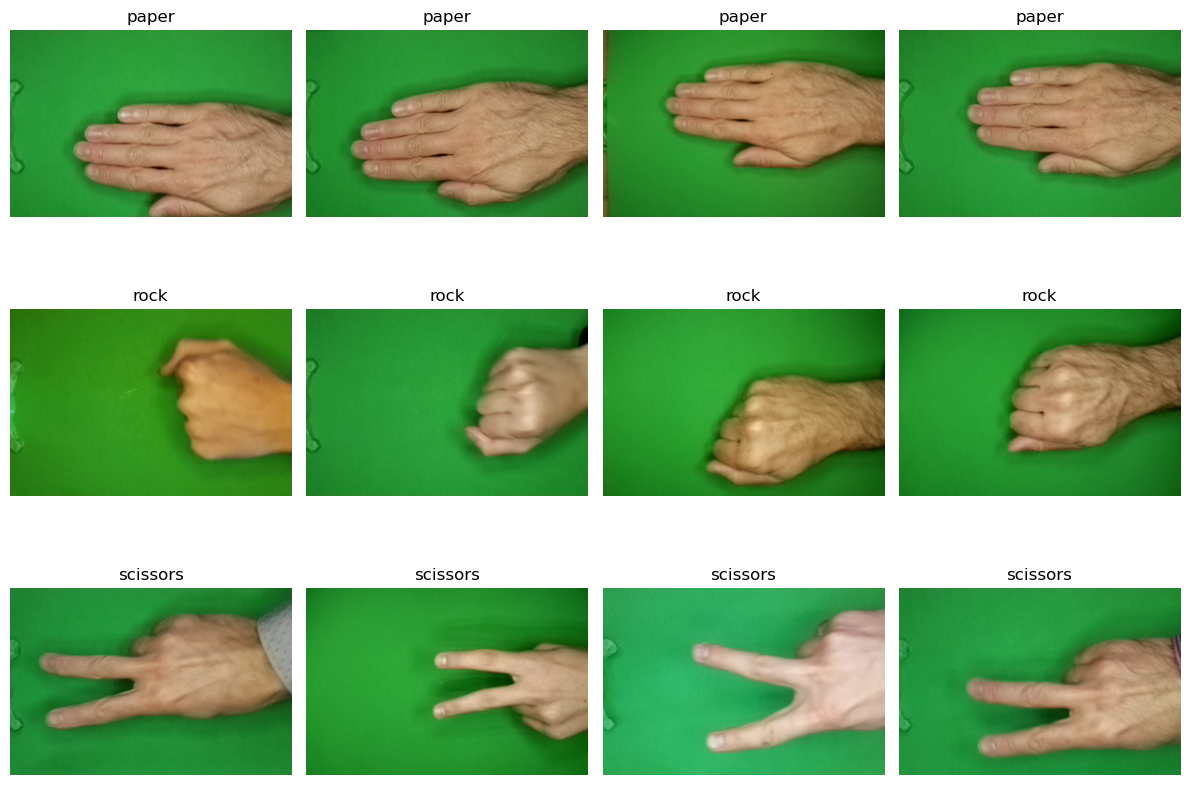

In [1]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def explore_dataset(data_dir):
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    total_images = 0
    class_counts = {}
    
    # Using a list to sample pixel values to compute global statistics without overloading RAM
    sampled_pixel_values = []
    
    print("--- 1. Quantitative & Technical Analysis ---")
    for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        # Filter out hidden files like .DS_Store (common on macOS)
        images = [img for img in os.listdir(cls_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        num_images = len(images)
        class_counts[cls] = num_images
        total_images += num_images
        
        sizes = set()
        modes = set()
        brightness_values = []
        accumulated_array = None
        
        print(f"\nClass: {cls}")
        print(f" - Images count: {num_images}")
        
        for i in images:
            img_path = os.path.join(cls_dir, i)
            with Image.open(img_path) as img:
                modes.add(img.mode)
                
                if img.mode != "RGB":
                    img = img.convert("RGB")
                    
                sizes.add(img.size)
                img_array = np.array(img, dtype=np.float64)
                
                # Initialize accumulator with the shape of the first loaded image
                if accumulated_array is None:
                    accumulated_array = np.zeros_like(img_array)
                    
                if img_array.shape == accumulated_array.shape:
                    accumulated_array += img_array
                
                # CCIR 601 luma formula
                brightness = np.mean(0.299 * img_array[:,:,0] + 0.587 * img_array[:,:,1] + 0.114 * img_array[:,:,2])
                brightness_values.append(brightness)
                
                # Randomly sample pixels from 5% of images for global dataset statistics
                if random.random() < 0.05:
                    sampled_pixel_values.extend(img_array.flatten()[::100]) # taking every 100th pixel to save memory
        
        avg_img = (accumulated_array / num_images) / 255.0
        
        print(f" - Image sizes encountered (W, H): {list(sizes)}")
        print(f" - Color modes encountered: {list(modes)}")
        print(f" - Mean Brightness: {np.mean(brightness_values):.2f}")
        print(f" - Std Brightness: {np.std(brightness_values):.2f}")
        
        plt.figure(figsize=(3, 3))
        plt.imshow(avg_img)
        plt.title(f"Average Image - {cls}")
        plt.axis("off")
        plt.show()

    print("\n--- Overall Dataset Statistics ---")
    print(f"Total images: {total_images}")
    if sampled_pixel_values:
        print(f"Global Pixel Min: {np.min(sampled_pixel_values)}")
        print(f"Global Pixel Max: {np.max(sampled_pixel_values)}")
        print(f"Global Pixel Mean: {np.mean(sampled_pixel_values):.2f}")
        print(f"Global Pixel Std: {np.std(sampled_pixel_values):.2f}")

    # Plot class distribution
    plt.figure(figsize=(6, 4))
    plt.bar(class_counts.keys(), class_counts.values(), color=['salmon', 'lightgreen', 'lightblue'])
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print("\n--- 2. Qualitative Inspection ---")
    # Display a grid of random samples for visual inspection
    samples_per_class = 4
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 3, len(classes) * 3))
    
    for row_idx, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        images = [img for img in os.listdir(cls_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sampled_images = random.sample(images, min(samples_per_class, len(images)))
        
        for col_idx, img_name in enumerate(sampled_images):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            
            # Handle 1D or 2D subplots array depending on the number of classes
            ax = axes[row_idx, col_idx] if len(classes) > 1 else axes[col_idx]
            ax.imshow(img)
            ax.set_title(f"{cls}")
            ax.axis("off")
            
    plt.tight_layout()
    plt.show()

explore_dataset("../data/raw")